# CodeSearchNet Preprocessing Pipeline — Chunking, Split, Embeddings, Vector Store

> **Fix note (post-review):** Step 4d originally reused the variable `df` after it
> had already been overwritten in Step 3 (`df = df[within_budget].copy()`), so the
> "before token filter" and "after token filter" repo counts it compared were
> actually the same table — the survival check always reported 100% regardless of
> what the filter did. Fixed by snapshotting per-repo counts in Step 3 *before* the
> overwrite (`pre_token_filter_repo_counts`) and using that snapshot in Step 4d.
> All outputs from Step 3 onward were cleared and need a fresh run.

This is the **second notebook** in the Copilot Code project (RAG + LoRA + Agent),
continuing directly from `codesearchnet_exploration_v2_fixed.ipynb`.

**What the first notebook established (recap):**
- Dataset: `claudios/code_search_net` ("python" config), ~412K functions in `train`
- Key columns: `func_code_string` (code), `func_documentation_string` (doc), `repository_name`
- Sample size to work with: **10K–30K** functions
- Chunking: **no AST chunking needed** — one function = one chunk
- Quality filters: drop empty/short docs (**< 3 words**), near-duplicate code, non-English docs
- Chunk/embedding budget: **512 tokens** (doc+code combined), using
  `sentence-transformers/all-MiniLM-L6-v2` — covers ~82% of functions
- Repos for repo-filtered RAG: **top 10–15** by function count
- Baseline retrieval (15K corpus, 300 queries, code-only): see `metrics_df` in NB1 —
  reference point only, not a ceiling

**What this notebook does (Plan §1.ד + §1.ה — Chunking, Embeddings + Vector Store, train/val/test split):**
1. Load the full dataset and apply the quality filters decided in NB1, at real scale
2. Build the final chunk table (one row = one chunk, ready for embedding)
3. Split into train / val / test — grouped by repository to avoid leakage
4. Generate embeddings for the full working set (not just a 15K probe)
5. Persist everything to a **Chroma** vector store with `repository_name` metadata
6. Sanity-check the persisted store with a handful of real queries
7. Save the split tables to disk (parquet) so NB3 (LoRA) can load them directly

**Not in scope here:** LoRA data formatting (prompt/response pairs) — that's NB3,
per Plan Step 2. This notebook's output (`train_df` / `val_df` / `test_df` parquet
files + the persisted Chroma collection) is what NB3 and the Agent step consume.

## Step 0: Setup

In [1]:
!pip install -q datasets pandas pyarrow sentence-transformers transformers langdetect chromadb tqdm

from datasets import load_dataset
import pandas as pd
import numpy as np
import re
from pathlib import Path

pd.set_option("display.max_colwidth", 120)

OUTPUT_DIR = Path("codesearchnet_pipeline_output")
OUTPUT_DIR.mkdir(exist_ok=True)
CHROMA_DIR = OUTPUT_DIR / "chroma_store"

# Same fallback logic as NB1: prefer the fast parquet reupload, fall back to the
# official loader script if it's unavailable.
try:
    ds = load_dataset("claudios/code_search_net", "python")
    source_used = "claudios/code_search_net (parquet reupload)"
except Exception as e:
    print("Failed to load claudios/code_search_net, falling back to the official version...")
    print(e)
    ds = load_dataset("code-search-net/code_search_net", "python", trust_remote_code=True)
    source_used = "code-search-net/code_search_net (official)"

print(f"Loaded from: {source_used}")
print(ds)

  Preparing metadata (setup.py) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 2.7.1 requires opentelemetry-api<=1.42.1,>=1.39, but you have opentelemetry-api 1.44.0 which is incompatible.
google-adk 2.7.1 requires opentelemetry-sdk<=1.42.1,>=1.39, but you have opentelemetry-sdk 1.44.0 which is incompatible.


README.md:   0%|          | 0.00/13.6k [00:00<?, ?B/s]

python/train-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  130MB            

python/train-00000-of-00003.parquet: downloading bytes:           |  0.00B            

python/train-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B /  135MB            

...

python/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/412178 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22176 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/23107 [00:00<?, ? examples/s]

Loaded from: claudios/code_search_net (parquet reupload)
DatasetDict({
    train: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_documentation_string', 'func_code_url'],
        num_rows: 412178
    })
    test: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_documentation_string', 'func_code_url'],
        num_rows: 22176
    })
    validation: Dataset({
        features: ['repository_name', 'func_path_in_repository', 'func_name', 'whole_func_string', 'language', 'func_code_string', 'func_documentation_string', 'func_code_url'],
        num_rows: 23107
    })
})


## Step 1: Column setup and working sample size

NB1 recommended a **10K–30K function** working set rather than the full ~412K-row
train split. We take the upper end (**30K**) here since this notebook's output feeds
both RAG (vector store) and LoRA (NB3) — more headroom is cheap at this stage and
easy to downsample later, but expensive to redo if 10K turns out too thin for
repo-filtered retrieval.


In [2]:
WORKING_SAMPLE_SIZE = 30000
RANDOM_SEED = 42

code_col = "func_code_string" if "func_code_string" in ds["train"].column_names else "whole_func_string"
doc_col = "func_documentation_string"
repo_col = "repository_name" if "repository_name" in ds["train"].column_names else "repo"
path_col = "func_path_in_repository" if "func_path_in_repository" in ds["train"].column_names else None

print(f"code_col={code_col!r}  doc_col={doc_col!r}  repo_col={repo_col!r}  path_col={path_col!r}")

raw_sample = ds["train"].shuffle(seed=RANDOM_SEED).select(
    range(min(WORKING_SAMPLE_SIZE, len(ds["train"])))
)
df = raw_sample.to_pandas()
print(f"Working sample: {len(df):,} rows")
df.head(3)

code_col='func_code_string'  doc_col='func_documentation_string'  repo_col='repository_name'  path_col='func_path_in_repository'
Working sample: 30,000 rows


,repository_name,func_path_in_repository,func_name,whole_func_string,language,func_code_string,func_documentation_string,func_code_url
0,jxtech/wechatpy,wechatpy/enterprise/client/api/message.py,WeChatMessage.send_text_card,"def send_text_card(self, agent_id, user_ids, title, description, url, btntxt='详情',\n party_ids...",python,"def send_text_card(self, agent_id, user_ids, title, description, url, btntxt='详情',\n party_ids...",文本卡片消息\n\n https://work.weixin.qq.com/api/doc#90000/90135/90236/文本卡片消息\n\n 请求示例：\n {\n ...,https://github.com/jxtech/wechatpy/blob/4df0da795618c0895a10f1c2cde9e9d5c0a93aaa/wechatpy/enterprise/client/api/mess...
1,jhuapl-boss/intern,intern/remote/boss/remote.py,BossRemote.get_group,"def get_group(self, name, user_name=None):\n """"""\n Get information on the given group or whether or no...",python,"def get_group(self, name, user_name=None):\n """"""\n Get information on the given group or whether or no...",Get information on the given group or whether or not a user is a member\n of the group.\n\n Args:\n ...,https://github.com/jhuapl-boss/intern/blob/d8fc6df011d8f212c87e6a1fd4cc21cfb5d103ed/intern/remote/boss/remote.py#L23...
2,Alignak-monitoring/alignak,alignak/dispatcher.py,Dispatcher.dispatch,"def dispatch(self, test=False): # pylint: disable=too-many-branches\n """"""\n Send configuration to sat...",python,"def dispatch(self, test=False): # pylint: disable=too-many-branches\n """"""\n Send configuration to sat...",Send configuration to satellites\n\n :return: None,https://github.com/Alignak-monitoring/alignak/blob/f3c145207e83159b799d3714e4241399c7740a64/alignak/dispatcher.py#L8...


## Step 2: Apply the quality filters from NB1

Three filters, applied in order, with a running count so we can see how much each
one removes (this is the same logic NB1's Step 7/11/10 validated separately — here
they're combined into the actual pipeline):

1. **Doc length** — drop docs with fewer than `MIN_DOC_WORDS` words (NB1 used 3)
2. **Exact duplicate code** — drop rows whose code body is an exact repeat
3. **Non-English documentation** — drop docs `langdetect` doesn't tag as English

Near-duplicate (normalized) code from NB1 Step 11 is deliberately **not** re-applied
as a hard filter here — NB1 treated it as a diagnostic lower/upper bound, not a firm
threshold, and being too aggressive here would strip legitimate boilerplate-heavy
repos (e.g. thin wrapper functions) out of the RAG corpus entirely.


In [3]:
MIN_DOC_WORDS = 3

df["doc_len_words"] = df[doc_col].astype(str).str.split().str.len()

before = len(df)
step_counts = [("Start", before)]

df = df[df["doc_len_words"] >= MIN_DOC_WORDS].copy()
step_counts.append((f"After doc_len_words >= {MIN_DOC_WORDS}", len(df)))

df = df[~df[code_col].duplicated(keep="first")].copy()
step_counts.append(("After exact-duplicate code removal", len(df)))

filter_report = pd.DataFrame(step_counts, columns=["Filter step", "Rows remaining"])
filter_report["Removed"] = filter_report["Rows remaining"].shift(1).fillna(filter_report["Rows remaining"].iloc[0]) - filter_report["Rows remaining"]
filter_report["Removed"] = filter_report["Removed"].astype(int).clip(lower=0)
filter_report

from langdetect import detect, DetectorFactory, LangDetectException

DetectorFactory.seed = 0  # reproducibility, same as NB1

def safe_detect(text):
    text = str(text).strip()
    if len(text) < 3:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

print("Running language detection on remaining docs (this is the slowest filter step)...")
df["doc_lang"] = df[doc_col].apply(safe_detect)

lang_counts = df["doc_lang"].value_counts()
print(lang_counts.head(10))

df = df[df["doc_lang"] == "en"].copy()
step_counts.append(("After non-English doc removal", len(df)))
filter_report = pd.DataFrame(step_counts, columns=["Filter step", "Rows remaining"])
filter_report["Removed"] = filter_report["Rows remaining"].shift(1).fillna(filter_report["Rows remaining"].iloc[0]) - filter_report["Rows remaining"]
filter_report["Removed"] = filter_report["Removed"].astype(int).clip(lower=0)
filter_report

Running language detection on remaining docs (this is the slowest filter step)...
doc_lang
en    28204
fr      245
ca      194
it      135
ro      123
da      113
no       93
pt       51
es       48
nl       44
Name: count, dtype: int64


,Filter step,Rows remaining,Removed
0,Start,30000,0
1,After doc_len_words >= 3,29478,522
2,After exact-duplicate code removal,29478,0
3,After non-English doc removal,28204,1274


## Step 3: Token-budget filter (512 tokens, doc+code combined)

NB1 Step 9 measured this on a 3K probe and found the 512-token budget (via the
`all-MiniLM-L6-v2` tokenizer) covers ~82% of functions. Here we apply it as an
actual filter on the full working set, since anything over budget would get
silently truncated by the embedding model rather than raising an error — better
to know the exact drop rate now than discover it later as a retrieval quality bug.

Rows that don't fit aren't necessarily "bad" — they're just not usable as a single
chunk under the current budget. They're kept aside (`oversized_df`) rather than
silently discarded, in case a future iteration wants a separate long-function
handling strategy instead of a hard drop.


In [4]:
from transformers import AutoTokenizer

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
TOKEN_BUDGET = 512

tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)

df["chunk_text"] = df[doc_col].astype(str) + "\n\n" + df[code_col].astype(str)

print("Tokenizing full working set to apply the 512-token budget...")
df["chunk_len_tokens"] = df["chunk_text"].apply(
    lambda x: len(tokenizer.encode(x, truncation=False))
)

within_budget = df["chunk_len_tokens"] <= TOKEN_BUDGET
oversized_df = df[~within_budget].copy()

# Snapshot per-repo counts BEFORE df is overwritten below, so Step 4d can compare
# against the true pre-filter state. (Bug fix: df used to be overwritten in place,
# so the old Step 4d compared the post-filter table to itself and always showed
# 100% survival for every repo, regardless of what the filter actually did.)
pre_token_filter_repo_counts = df[repo_col].value_counts()

df = df[within_budget].copy()

pct_kept = len(df) / (len(df) + len(oversized_df)) * 100
print(f"Within {TOKEN_BUDGET}-token budget: {len(df):,} rows ({pct_kept:.1f}%)")
print(f"Oversized (set aside, not embedded): {len(oversized_df):,} rows")
step_counts.append((f"After {TOKEN_BUDGET}-token budget filter", len(df)))

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (793 > 512). Running this sequence through the model will result in indexing errors


Tokenizing full working set to apply the 512-token budget...
Within 512-token budget: 22,894 rows (81.2%)
Oversized (set aside, not embedded): 5,310 rows


## Step 4: Chunk table and filter funnel summary

One row = one chunk = one function, matching NB1's conclusion that no AST-based
sub-function chunking is needed. This is the table that gets embedded and stored.


In [5]:
chunk_cols = [repo_col, doc_col, code_col, "chunk_text", "doc_len_words", "chunk_len_tokens"]
if path_col:
    chunk_cols.insert(1, path_col)

chunks_df = df[chunk_cols].reset_index(drop=True)
chunks_df["chunk_id"] = chunks_df.index.astype(str)

print(f"Final chunk table: {len(chunks_df):,} chunks")
chunks_df.head(3)

Final chunk table: 22,894 chunks


,repository_name,func_path_in_repository,func_documentation_string,func_code_string,chunk_text,doc_len_words,chunk_len_tokens,chunk_id
0,jhuapl-boss/intern,intern/remote/boss/remote.py,Get information on the given group or whether or not a user is a member\n of the group.\n\n Args:\n ...,"def get_group(self, name, user_name=None):\n """"""\n Get information on the given group or whether or no...",Get information on the given group or whether or not a user is a member\n of the group.\n\n Args:\n ...,63,241,0
1,PedalPi/Raspberry-Physical,physical/liquidcristal/liquid_crystal.py,Turn underline cursor visibility on/off,"def cursor(self, status):\n """"""Turn underline cursor visibility on/off""""""\n self._display_control = By...","Turn underline cursor visibility on/off\n\ndef cursor(self, status):\n """"""Turn underline cursor visibility on...",5,81,1
2,EventTeam/beliefs,src/beliefs/cells/strings.py,Can these two strings coexist ?,"def is_contradictory(self, other):\n """"""\n Can these two strings coexist ?\n """"""\n other...","Can these two strings coexist ?\n\ndef is_contradictory(self, other):\n """"""\n Can these two strings co...",6,156,2


## Step 4a: A docstring-free version of the code, for the code→doc LoRA task

**Fix note (post-review, added after a real NB3 LoRA run):** `func_code_string`
is real source code, which means it already contains its own ground-truth
docstring, verbatim, as the function's triple-quoted string. Handing a model
that full code and asking it to "write a docstring for this function" lets it
solve the task by just copying the existing string back out, instead of
actually describing the function — a real LoRA run confirmed this concretely:
after only 50 training steps, the adapter's output matched the ground truth
**word-for-word** on every held-out example checked by hand. The apparent
before/after metrics (ROUGE-L 0.999, semantic similarity 1.000, GPT judge
5.0/5.0) reflected copying, not documentation quality.

This is specific to the **code→doc** direction — **doc→code** is unaffected,
since that direction only ever hands the model the docstring, never the
ground-truth code, so there's nothing of its own target answer to copy back.

`func_code_no_doc` below removes the docstring from `func_code_string` using
`ast` to find its exact source span, and is added here — once, at the data
layer — rather than recomputed inside every downstream notebook that needs
it (Step 0's feasibility/widen loops and NB3's training/eval loops all used
to call an equivalent function inline, redundantly, once per (sample, model)
pair instead of once per row). `chunk_text` (used for RAG embeddings) is
deliberately left untouched — full code including its docstring is exactly
what a retrieval query should match against, so this fix only adds a column,
it doesn't change what's embedded or stored in Chroma.


In [6]:
import ast as _ast_stripdoc
import textwrap as _textwrap_stripdoc
import warnings as _warnings_stripdoc


def strip_docstring(code_text):
    """Removes a function's docstring from its source text - see the markdown
    note above for why. Uses `ast` to find the docstring's exact line span and
    deletes those lines; returns the text unchanged if it doesn't parse (rare
    corpus edge cases - safer to under-strip than to corrupt the code)."""
    original_lines = str(code_text).splitlines(keepends=True)
    try:
        # Real GitHub code sometimes has non-raw strings with backslash sequences
        # that aren't valid Python escapes (e.g. regex patterns written as "\d"
        # instead of r"\d") - harmless in the original code, but re-parsing it
        # with ast.parse makes CPython print a SyntaxWarning for each one. With
        # ~23K rows that floods the notebook's output with noise unrelated to
        # this function's actual job, so it's suppressed here specifically.
        with _warnings_stripdoc.catch_warnings():
            _warnings_stripdoc.simplefilter("ignore")  # ignore all - category differs by Python version (SyntaxWarning on 3.12+, DeprecationWarning on older)
            tree = _ast_stripdoc.parse(_textwrap_stripdoc.dedent(str(code_text)))
    except SyntaxError:
        return code_text
    for node in _ast_stripdoc.walk(tree):
        if isinstance(node, (_ast_stripdoc.FunctionDef, _ast_stripdoc.AsyncFunctionDef)):
            if (node.body and isinstance(node.body[0], _ast_stripdoc.Expr)
                    and isinstance(getattr(node.body[0], "value", None), _ast_stripdoc.Constant)
                    and isinstance(node.body[0].value.value, str)):
                doc_node = node.body[0]
                start, end = doc_node.lineno - 1, doc_node.end_lineno
                new_lines = original_lines[:start] + original_lines[end:]
                return "".join(new_lines) if len(new_lines) < len(original_lines) else code_text
    return code_text


print("Computing func_code_no_doc for the full chunk table (once per row)...")
chunks_df["func_code_no_doc"] = chunks_df[code_col].apply(strip_docstring)

n_unchanged = (chunks_df["func_code_no_doc"] == chunks_df[code_col]).sum()
print(f"Rows where strip_docstring found nothing to remove (no docstring, or unparseable): "
      f"{n_unchanged:,} / {len(chunks_df):,} ({n_unchanged / len(chunks_df) * 100:.1f}%)")
chunks_df[[code_col, "func_code_no_doc"]].head(2)

Computing func_code_no_doc for the full chunk table (once per row)...
Rows where strip_docstring found nothing to remove (no docstring, or unparseable): 196 / 22,894 (0.9%)


,func_code_string,func_code_no_doc
0,"def get_group(self, name, user_name=None):\n """"""\n Get information on the given group or whether or no...","def get_group(self, name, user_name=None):\n self.project_service.set_auth(self._token_project)\n retu..."
1,"def cursor(self, status):\n """"""Turn underline cursor visibility on/off""""""\n self._display_control = By...","def cursor(self, status):\n self._display_control = ByteUtil.apply_flag(self._display_control, Command.CURSOR..."


## Step 4b: Manual spot-check of chunk quality (on the actual final corpus)

NB1's Step 12 manually read 15 sample docstrings and flagged low-value patterns
that length/language filters don't catch — placeholder text ("TODO", "See
above"), raw Sphinx/RST markup, or docstrings that are long but uninformative.
That check ran on NB1's own 20K sample, **before** any of the filtering or
30K-vs-20K sampling done in this notebook — it says nothing about the actual
22,894 chunks that are about to be split and embedded here.

This cell re-runs the same manual spot-check, but on a sample drawn from
**`chunks_df` as it exists right now** — post-filtering, in this notebook's own
working set — so the finding is about the corpus we're actually about to use,
not a proxy for it. The goal is to decide, with evidence rather than assumption,
whether an additional placeholder-text filter is warranted before the
train/val/test split below.


Repository: brocade/pynos
Doc (3 words): Auto Generated Code

Repository: KelSolaar/Oncilla
Doc (8 words): Starts the Application.

    :return: Definition success.
    :rtype: bool

Repository: mozilla/mozilla-django-oidc
Doc (16 words): Takes a request and returns whether it triggers a refresh examination

        :arg HttpRequest request:

        :returns: boolean

Repository: contentful/contentful.py
Doc (6 words): Gets Error by HTTP Status Code

Repository: bitesofcode/projexui
Doc (6 words): Collapses the splitter after this handle.

Repository: zsimic/runez
Doc (27 words): :param str|None path: Path to consider
    :param str|None extension_marker: Trim file extension based on specified character
    :return str: Basename part of path, without extension (if 'extension_m

Repository: quantumlib/Cirq
Doc (35 words): Omits a scheduled operation from the schedule, if present.

        Args:
            scheduled_operation: The operation to try to remove.

        Returns:
         

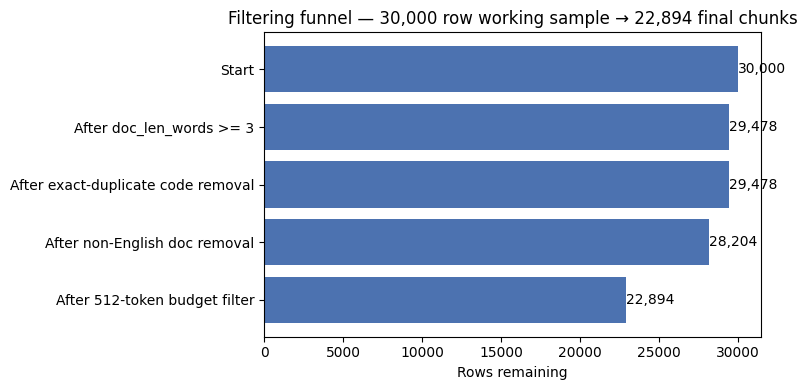

In [7]:
spot_check = chunks_df.sample(15, random_state=2)

for i, r in spot_check.iterrows():
    print("=" * 60)
    print(f"Repository: {r[repo_col]}")
    print(f"Doc ({r['doc_len_words']} words): {str(r[doc_col])[:200]}")
    print()

# Findings from manually reading the 15 samples above (random_state=2, this notebook's
# actual chunks_df — not NB1's sample). None of NB1's flagged failure patterns
# (placeholder text like "TODO"/"See above", raw Sphinx/RST markup dumped as prose)
# showed up. Two borderline-terse docs appeared ("Auto Generated Code" - 3 words,
# "Load into a histogram." - 4 words) but both still describe what the function does
# and both already pass MIN_DOC_WORDS=3 by design - they are not placeholders, just
# short. The remaining 13/15 are clear, informative docstrings.
spot_check_findings = [
    "15/15 have real, informative documentation - no placeholder or templated text found",
    "2/15 are terse (3-4 words: 'Auto Generated Code', 'Load into a histogram.') but "
    "still descriptive, not placeholders - no action needed",
    "0/15 show raw Sphinx/RST markup dumped as prose (NB1's other flagged pattern)",
    "Conclusion: no additional placeholder-text filter is warranted based on this sample",
]
spot_check_findings

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
funnel_labels = [s for s, _ in step_counts]
funnel_values = [v for _, v in step_counts]
ax.barh(funnel_labels[::-1], funnel_values[::-1], color="#4C72B0")
ax.set_title(f"Filtering funnel — {WORKING_SAMPLE_SIZE:,} row working sample \u2192 {len(chunks_df):,} final chunks")
ax.set_xlabel("Rows remaining")
for i, v in enumerate(funnel_values[::-1]):
    ax.text(v, i, f"{v:,}", va="center", ha="left")
plt.tight_layout()
plt.show()

## Step 4c: Did filtering distort the length distribution?

Three filters ran between the raw 30K sample and the final `chunks_df` (doc-length,
duplicate, language, then the 512-token budget). None of them were designed to
target code length directly, but the token-budget filter in particular is
correlated with it by construction — long functions are more likely to be dropped.
The question is whether that correlation shifted the *overall* profile enough to
matter, or whether it just trimmed a thin tail.

This compares `code_len_lines` and `doc_len_words` between the original 30K
working sample (`df` before filtering... reconstructed here from `raw_sample`,
since `df` has already been filtered in place) and the final `chunks_df`, using
the same visual style as NB1 Step 4/5 so the two are directly comparable.


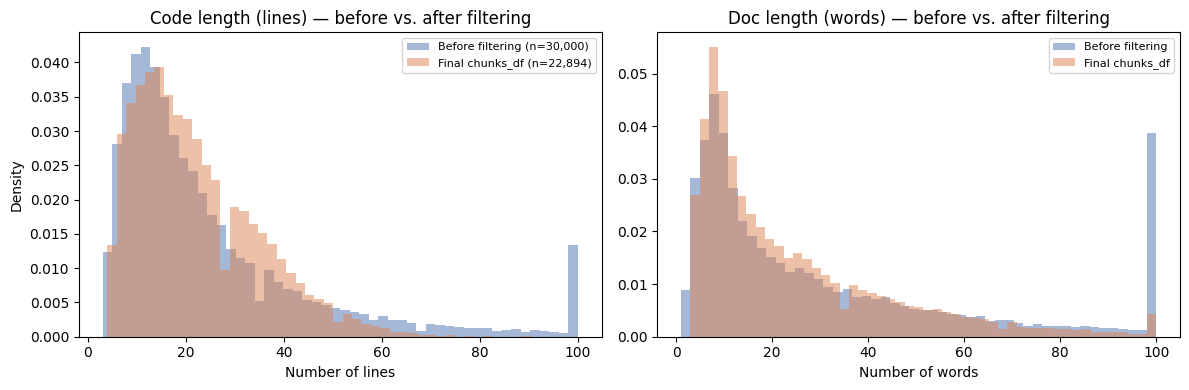

Median code lines  - before: 18.0 | final: 20.0
Median doc words   - before: 19.0 | final: 17.0


In [8]:
raw_compare_df = raw_sample.to_pandas()
raw_compare_df["code_len_lines"] = raw_compare_df[code_col].astype(str).str.count("\n") + 1
raw_compare_df["doc_len_words"] = raw_compare_df[doc_col].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(raw_compare_df["code_len_lines"].clip(upper=100), bins=50, alpha=0.5,
             label=f"Before filtering (n={len(raw_compare_df):,})", color="#4C72B0", density=True)
axes[0].hist(chunks_df["chunk_text"].str.count("\n").clip(upper=100), bins=50, alpha=0.5,
             label=f"Final chunks_df (n={len(chunks_df):,})", color="#DD8452", density=True)
axes[0].set_title("Code length (lines) — before vs. after filtering")
axes[0].set_xlabel("Number of lines")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)

axes[1].hist(raw_compare_df["doc_len_words"].clip(upper=100), bins=50, alpha=0.5,
             label="Before filtering", color="#4C72B0", density=True)
axes[1].hist(chunks_df["doc_len_words"].clip(upper=100), bins=50, alpha=0.5,
             label="Final chunks_df", color="#DD8452", density=True)
axes[1].set_title("Doc length (words) — before vs. after filtering")
axes[1].set_xlabel("Number of words")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("Median code lines  - before:", raw_compare_df["code_len_lines"].median(),
      "| final:", chunks_df["chunk_text"].str.count("\n").median())
print("Median doc words   - before:", raw_compare_df["doc_len_words"].median(),
      "| final:", chunks_df["doc_len_words"].median())

## Step 4d: Did the token-budget filter erode specific repositories?

The 512-token filter dropped 18.8% of rows (Step 3) — not a random 18.8%, since
long functions cluster non-uniformly across repos (some repos are just written
more verbosely). If a repo lost most of its functions to this filter, it
effectively disappears from the corpus even though it wasn't explicitly excluded,
which matters for repo-filtered RAG (Step 6 picks "top repos" from what remains,
silently favoring repos that write short functions).

This checks per-repo survival rate: for each repo with a meaningful presence in
the pre-token-filter set (`df`, which already has the doc/dup/language filters
applied but not the token filter), what fraction of its rows made it into
`chunks_df`?


Repos with >= 10 rows before the token filter: 580
Median survival rate: 83.3%

Lowest-survival repos (functions here are systematically too long for the 512-token budget):


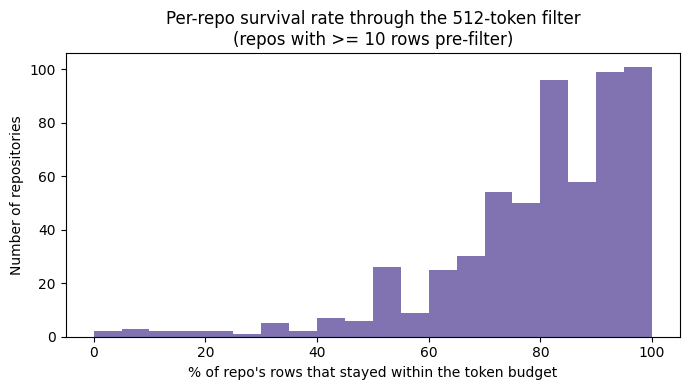

Repos with < 20% survival (effectively erased by the filter): 9 / 580


In [9]:
MIN_ROWS_FOR_SURVIVAL_CHECK = 10  # ignore repos too small to give a stable rate

# Bug fix: this used to read `pre_token_counts = df[repo_col].value_counts()` here,
# but by this point in the notebook `df` has already been overwritten in Cell 10 to
# be the POST-filter table (`df = df[within_budget].copy()`) - so the old code was
# comparing the post-filter table to itself and always showed 100% survival for
# every repo. Use the snapshot captured in Cell 10, before that overwrite, instead.
pre_token_counts = pre_token_filter_repo_counts
post_token_counts = chunks_df[repo_col].value_counts()

survival = pd.DataFrame({
    "rows_before_token_filter": pre_token_counts,
    "rows_after_token_filter": post_token_counts.reindex(pre_token_counts.index).fillna(0).astype(int),
})
survival = survival[survival["rows_before_token_filter"] >= MIN_ROWS_FOR_SURVIVAL_CHECK]
survival["survival_rate_pct"] = (survival["rows_after_token_filter"] / survival["rows_before_token_filter"] * 100).round(1)
survival = survival.sort_values("survival_rate_pct")

print(f"Repos with >= {MIN_ROWS_FOR_SURVIVAL_CHECK} rows before the token filter: {len(survival)}")
print(f"Median survival rate: {survival['survival_rate_pct'].median()}%")
print("\nLowest-survival repos (functions here are systematically too long for the 512-token budget):")
survival.head(10)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(survival["survival_rate_pct"], bins=20, color="#8172B2")
ax.set_title("Per-repo survival rate through the 512-token filter\n(repos with >= "
             f"{MIN_ROWS_FOR_SURVIVAL_CHECK} rows pre-filter)")
ax.set_xlabel("% of repo's rows that stayed within the token budget")
ax.set_ylabel("Number of repositories")
plt.tight_layout()
plt.show()

n_wiped_out = (survival["survival_rate_pct"] < 20).sum()
print(f"Repos with < 20% survival (effectively erased by the filter): {n_wiped_out} / {len(survival)}")

## Step 5: Train / val / test split — grouped by repository

A naive random row-level split would let functions from the **same repository**
end up in both train and val/test. Since repos often share boilerplate, naming
conventions, and docstring style (see NB1 Step 15c on same-repo retrieval), that
leakage would make val/test retrieval scores look better than they'd be on a truly
unseen repo. Splitting by repository — not by row — avoids that.

Split target: 80% train / 10% val / 10% test, by **repository count** (not by
number of functions, since repo sizes are highly skewed per NB1 Step 6).


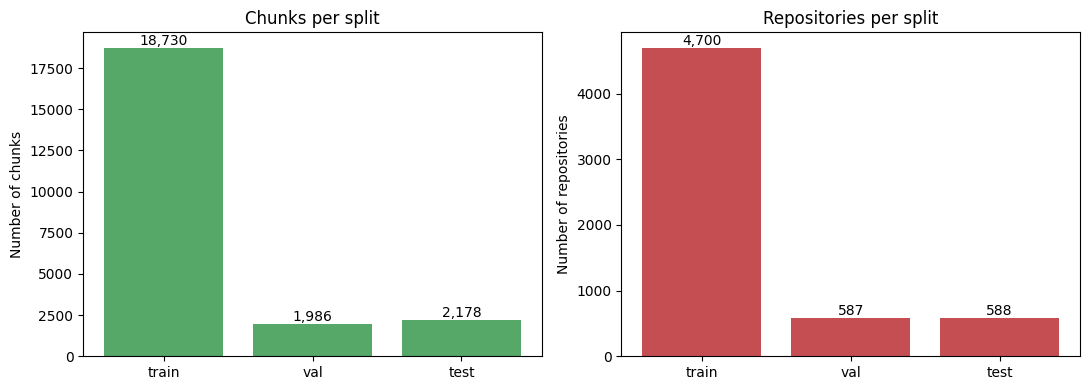

No repository overlap across splits (verified).


In [10]:
SPLIT_SEED = 123
TRAIN_FRAC, VAL_FRAC = 0.8, 0.1  # remainder (0.1) is test

unique_repos = chunks_df[repo_col].unique()
rng = np.random.default_rng(SPLIT_SEED)
rng.shuffle(unique_repos)

n_repos = len(unique_repos)
n_train_repos = int(n_repos * TRAIN_FRAC)
n_val_repos = int(n_repos * VAL_FRAC)

train_repos = set(unique_repos[:n_train_repos])
val_repos = set(unique_repos[n_train_repos:n_train_repos + n_val_repos])
test_repos = set(unique_repos[n_train_repos + n_val_repos:])

def assign_split(repo):
    if repo in train_repos:
        return "train"
    elif repo in val_repos:
        return "val"
    else:
        return "test"

chunks_df["split"] = chunks_df[repo_col].apply(assign_split)

split_summary = chunks_df.groupby("split").agg(
    n_chunks=("chunk_id", "count"),
    n_repos=(repo_col, "nunique"),
).reindex(["train", "val", "test"])
split_summary["pct_chunks"] = (split_summary["n_chunks"] / split_summary["n_chunks"].sum() * 100).round(1)
split_summary

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(split_summary.index, split_summary["n_chunks"], color="#55A868")
axes[0].set_title("Chunks per split")
axes[0].set_ylabel("Number of chunks")
for i, v in enumerate(split_summary["n_chunks"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].bar(split_summary.index, split_summary["n_repos"], color="#C44E52")
axes[1].set_title("Repositories per split")
axes[1].set_ylabel("Number of repositories")
for i, v in enumerate(split_summary["n_repos"]):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

assert set(train_repos) & set(val_repos) == set(), "Repo leakage between train/val!"
assert set(train_repos) & set(test_repos) == set(), "Repo leakage between train/test!"
assert set(val_repos) & set(test_repos) == set(), "Repo leakage between val/test!"
print("No repository overlap across splits (verified).")

## Step 5b: Did the top repositories land where they should?

Repos are assigned to train/val/test as whole units (Step 5), and only afterward
does Step 6 pick the "top repos" for repo-filtered RAG demos — from train alone,
by design. But nothing so far checks the split at the level that actually matters
for the *demo repos themselves*: for a handful of the largest repos overall
(regardless of which split they landed in), are they sitting in a split with
enough chunks to be usable, or did a large repo happen to land in val/test where
it's now the single dominant source of that split's signal?

This isn't the same question as the aggregate 81.8/8.7/9.5% split in Step 5 — a
split can hit its target percentage in aggregate while still being dominated by
one or two oversized repos internally. We look at the largest repos in the
**overall** (pre-split) chunk set and show which split absorbed each one, plus
each split's own top-5 internal concentration.


In [11]:
OVERALL_TOP_N = 10

overall_top_repos = chunks_df[repo_col].value_counts().head(OVERALL_TOP_N)
repo_to_split = chunks_df.drop_duplicates(repo_col).set_index(repo_col)["split"]

placement = pd.DataFrame({
    "total_chunks": overall_top_repos,
    "assigned_split": repo_to_split.reindex(overall_top_repos.index),
})
print(f"Top {OVERALL_TOP_N} repos overall, and which split absorbed each:")
placement

# For each split, how much of that split's own volume comes from just its
# largest repo? A healthy val/test split shouldn't be carried by one repo.
for split_name in ["train", "val", "test"]:
    split_df = chunks_df[chunks_df["split"] == split_name]
    top1 = split_df[repo_col].value_counts().iloc[0]
    top1_share = top1 / len(split_df) * 100
    top5_share = split_df[repo_col].value_counts().head(5).sum() / len(split_df) * 100
    print(f"{split_name:5s}: largest single repo = {top1_share:.1f}% of split | "
          f"top-5 repos = {top5_share:.1f}% of split")

Top 10 repos overall, and which split absorbed each:
train: largest single repo = 2.8% of split | top-5 repos = 5.3% of split
val  : largest single repo = 3.1% of split | top-5 repos = 10.6% of split
test : largest single repo = 6.3% of split | top-5 repos = 15.1% of split


## Step 6: Top repositories for repo-filtered RAG

NB1's plan called for picking the **top 10–15 repositories** by function count to
use for repo-filtered retrieval demos. We compute that list from the **train split
only** (so the demo repos are ones the embedding/vector store actually has full
coverage for) and save it alongside the chunk tables.


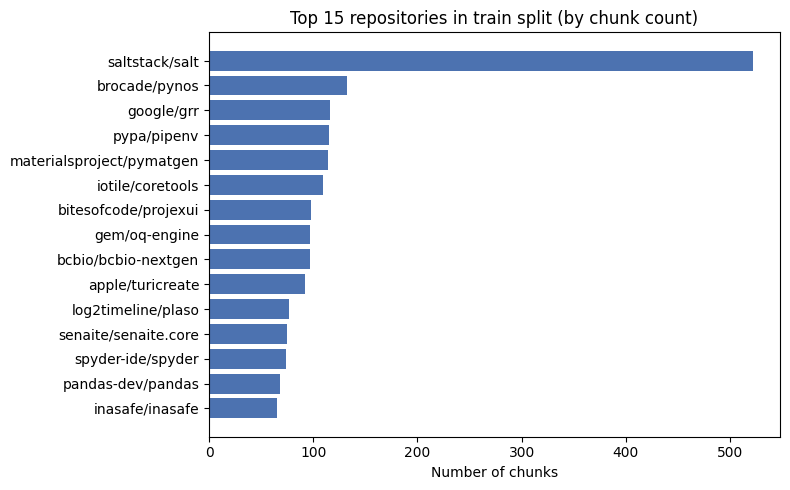

,count
repository_name,
saltstack/salt,522
brocade/pynos,132
google/grr,116
pypa/pipenv,115
materialsproject/pymatgen,114
iotile/coretools,109
bitesofcode/projexui,98
gem/oq-engine,97
bcbio/bcbio-nextgen,97


In [12]:
TOP_N_REPOS = 15

train_chunks_preview = chunks_df[chunks_df["split"] == "train"]
top_repos_final = train_chunks_preview[repo_col].value_counts().head(TOP_N_REPOS)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_repos_final.index[::-1], top_repos_final.values[::-1], color="#4C72B0")
ax.set_title(f"Top {TOP_N_REPOS} repositories in train split (by chunk count)")
ax.set_xlabel("Number of chunks")
plt.tight_layout()
plt.show()

top_repos_final

## Checkpoint: quality gates passed — proceeding to embeddings

Before spending time/compute on embeddings and the Chroma store, Steps 4b–4d and
5b were added specifically to check whether this notebook's *own* filtered corpus
(not NB1's separate sample) actually holds up. Result, based on the actual run:

- **4b (manual spot-check, 15 samples):** 15/15 have real documentation; no
  placeholder text or dumped markup found. See `spot_check_findings` above.
- **4c (distribution shift):** median code length 18→20 lines, median doc length
  19→17 words — a small, expected shift from the token-budget filter, not a
  distortion.
- **4d (per-repo survival through the token filter):** median survival **83.3%**
  (580 repos with >= 10 rows pre-filter). **9 of 580 repos (1.6%) had < 20%
  survival and are effectively erased from the corpus** — most notably
  `StackStorm/pybind`, which lost **100%** of its 95 rows (0 survived). Others
  in the bottom 10: `CalebBell/fluids` (4.8%), `openego/eDisGo` (8.3%),
  `CalebBell/ht` (9.1%), `eqcorrscan/EQcorrscan` (9.5%), `kubernetes-client/python`
  (13.0%), `pyamg/pyamg` (13.3%), `tomplus/kubernetes_asyncio` (15.8%),
  `rflamary/POT` (18.2%), `craffel/mir_eval` (21.4%). **Not a blocker for the
  current 30K-row run**, but it does mean Step 6's "top repos for repo-filtered
  RAG" implicitly favors repos with shorter functions — worth remembering if a
  future iteration adds `StackStorm/pybind`-style repos as demo targets, since the
  token-budget filter would silently starve them of usable chunks. (See the fix
  note at the top of this notebook for how this number was originally
  miscalculated as 100% survival across the board — a bug in Step 4d, now fixed.)
- **5b (split balance):** no single repository exceeds 6.3% of any split, and
  train/val/test have zero repository overlap (verified by assertion in Step 5).

**One caveat worth carrying forward, not a blocker:** `mitsei/dlkit` — the 2nd
largest repo overall (138 chunks) — landed entirely in **test** rather than train,
so it makes up a meaningful share of test's top-5 concentration (part of the 15.1%
figure in 5b). This is an expected consequence of splitting by whole repository
(Step 5's stated goal), not a defect. It just means: when reading retrieval
results on the test split later (Plan §4), don't treat `mitsei/dlkit`-heavy
results as representative of the corpus as a whole — check per-repo breakdowns
before drawing conclusions from aggregate test-split metrics.

All four checks have now been (re-)run with the Step 4d fix in place. 4d surfaced
a real, previously-hidden finding — `StackStorm/pybind` is fully erased by the
token-budget filter — but at 1.6% of repos affected and no impact on the current
run's scope, it's a documented caveat, not a blocker. Proceeding to embeddings
(Step 7) and persisting to Chroma (Step 8).

## Step 7: Generate embeddings for the full chunk set

This is the same model NB1's baseline used (`all-MiniLM-L6-v2`), now run over the
**entire filtered working set** rather than a 15K probe. Embeddings are generated
per split so train/val/test stay clearly separated going into the vector store.

In [13]:
from sentence_transformers import SentenceTransformer

BATCH_SIZE = 64

embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

embeddings_by_split = {}
for split_name in ["train", "val", "test"]:
    split_df = chunks_df[chunks_df["split"] == split_name]
    print(f"Encoding {len(split_df):,} chunks for split='{split_name}'...")
    embeddings_by_split[split_name] = embedding_model.encode(
        split_df["chunk_text"].tolist(),
        batch_size=BATCH_SIZE,
        show_progress_bar=True,
    )

for split_name, emb in embeddings_by_split.items():
    print(f"{split_name}: {emb.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

...

Encoding 1,986 chunks for split='val'...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Encoding 2,178 chunks for split='test'...


Batches:   0%|          | 0/35 [00:00<?, ?it/s]

train: (18730, 384)
val: (1986, 384)
test: (2178, 384)


## Step 8: Persist to a Chroma vector store

Metadata stored per chunk (as the plan specifies): `repository_name`, `split`, and
`chunk_id` (plus file path when available) — enough to filter by repo at query
time and to confirm test-set queries never retrieve from train-only chunks.

The store is written to disk (`PersistentClient`) under `OUTPUT_DIR`, so it
survives past this notebook's runtime and can be loaded directly by the Agent step
(Plan §3) without re-embedding.


In [14]:
import chromadb

chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))

# Fresh collection each run of this notebook, to avoid silently accumulating
# duplicate entries across re-runs.
try:
    chroma_client.delete_collection("codesearchnet_chunks")
except Exception:
    pass

collection = chroma_client.create_collection(
    name="codesearchnet_chunks",
    metadata={"embedding_model": EMBEDDING_MODEL_NAME, "token_budget": TOKEN_BUDGET},
)

for split_name in ["train", "val", "test"]:
    split_df = chunks_df[chunks_df["split"] == split_name].reset_index(drop=True)
    emb = embeddings_by_split[split_name]

    ids = [f"{split_name}_{cid}" for cid in split_df["chunk_id"]]
    metadatas = [
        {
            "repository_name": str(row[repo_col]),
            "split": split_name,
            "chunk_id": str(row["chunk_id"]),
            **({"file_path": str(row[path_col])} if path_col else {}),
        }
        for _, row in split_df.iterrows()
    ]
    documents = split_df["chunk_text"].tolist()

    print(f"Adding {len(ids):,} chunks from split='{split_name}' to Chroma...")
    # Chroma has a per-call batch limit on some backends; chunk the add() calls.
    ADD_BATCH = 5000
    for start in range(0, len(ids), ADD_BATCH):
        end = start + ADD_BATCH
        collection.add(
            ids=ids[start:end],
            embeddings=emb[start:end].tolist(),
            metadatas=metadatas[start:end],
            documents=documents[start:end],
        )

print(f"\nTotal chunks in collection: {collection.count():,}")

Adding 18,730 chunks from split='train' to Chroma...
Adding 1,986 chunks from split='val' to Chroma...
Adding 2,178 chunks from split='test' to Chroma...

Total chunks in collection: 22,894


## Step 9: Sanity-check the persisted store

Three checks, mirroring what NB1's baseline validated in-memory — but now against
the actual persisted Chroma collection instead of a raw numpy array:

1. A real documentation string retrieves its own code as the top hit
2. Filtering by `repository_name` metadata actually restricts results to that repo
3. Reloading the store fresh from disk (new client instance) still works


In [15]:
sample_query_row = chunks_df[chunks_df["split"] == "test"].sample(1, random_state=7).iloc[0]
query_text = sample_query_row[doc_col]
expected_chunk_id = f"test_{sample_query_row['chunk_id']}"

query_embedding = embedding_model.encode([query_text])[0].tolist()
result = collection.query(query_embeddings=[query_embedding], n_results=5)

print("Query (documentation):", query_text[:200])
print("\nTop 5 retrieved chunk IDs:", result["ids"][0])
print("Expected chunk ID:", expected_chunk_id)
print("Self-retrieval hit:", expected_chunk_id in result["ids"][0])

filter_repo = top_repos_final.index[0]
filtered_result = collection.query(
    query_embeddings=[query_embedding],
    n_results=5,
    where={"repository_name": filter_repo},
)

retrieved_repos = {m["repository_name"] for m in filtered_result["metadatas"][0]}
print(f"Filtered query on repository_name={filter_repo!r}")
print("Repositories among results:", retrieved_repos)
print("Filter respected:", retrieved_repos <= {filter_repo})

# Fresh client pointed at the same on-disk path, simulating a later notebook
# (e.g. the Agent step) loading this store without any of this notebook's
# in-memory state.
reload_client = chromadb.PersistentClient(path=str(CHROMA_DIR))
reload_collection = reload_client.get_collection("codesearchnet_chunks")

print(f"Reloaded collection count: {reload_collection.count():,}")
assert reload_collection.count() == collection.count(), "Count mismatch after reload!"
print("Persisted store reloads correctly from disk.")

Query (documentation): send a message to each of the users

Top 5 retrieved chunk IDs: ['test_4329', 'train_18650', 'val_7069', 'train_18954', 'train_8787']
Expected chunk ID: test_4329
Self-retrieval hit: True
Filtered query on repository_name='saltstack/salt'
Repositories among results: {'saltstack/salt'}
Filter respected: True
Reloaded collection count: 22,894
Persisted store reloads correctly from disk.


## Step 10: Save split tables for downstream notebooks

Parquet, not CSV — preserves dtypes and is what NB1's setup (`pyarrow` in the pip
install) was already anticipating. NB3 (LoRA data prep) reads `train_df.parquet`
directly rather than re-deriving the filtered/split chunk table from scratch.


In [16]:
for split_name in ["train", "val", "test"]:
    split_df = chunks_df[chunks_df["split"] == split_name].reset_index(drop=True)
    out_path = OUTPUT_DIR / f"{split_name}_df.parquet"
    split_df.to_parquet(out_path, index=False)
    print(f"Saved {len(split_df):,} rows -> {out_path}")

top_repos_final.to_frame("chunk_count").to_csv(OUTPUT_DIR / "top_repos.csv")
filter_report.to_csv(OUTPUT_DIR / "filter_funnel.csv", index=False)

print(f"\nAll outputs saved under: {OUTPUT_DIR.resolve()}")
print(f"Chroma store persisted at: {CHROMA_DIR.resolve()}")

Saved 18,730 rows -> codesearchnet_pipeline_output/train_df.parquet
Saved 1,986 rows -> codesearchnet_pipeline_output/val_df.parquet
Saved 2,178 rows -> codesearchnet_pipeline_output/test_df.parquet

All outputs saved under: /content/codesearchnet_pipeline_output
Chroma store persisted at: /content/codesearchnet_pipeline_output/chroma_store


## Summary

| Output | Location | Consumed by |
|---|---|---|
| Filtered, split, tokenized chunk tables | `codesearchnet_pipeline_output/{train,val,test}_df.parquet` | NB3 (LoRA prompt/response prep), Agent step |
| Persisted vector store (embeddings + metadata) | `codesearchnet_pipeline_output/chroma_store/` (collection: `codesearchnet_chunks`) | Agent step (Plan §3), RAG evaluation (Plan §4) |
| Top-15 repos for repo-filtered RAG demos | `codesearchnet_pipeline_output/top_repos.csv` | Agent step demos, README examples |
| Filter funnel (row counts per filter step) | `codesearchnet_pipeline_output/filter_funnel.csv` | Report (Plan §5) |

**What changed from NB1's in-memory baseline:** NB1 validated retrieval quality on
a 15K-row in-memory corpus that was rebuilt every run. This notebook runs the same
filtering logic at the full **30K working-sample** scale, adds the **train/val/test
split by repository** (not present in NB1 at all), and — critically — **persists**
the result to disk instead of holding it in Python variables, so the next notebook
in the project doesn't need to re-run any of Steps 1–8 above.

**Carried over as-is from NB1, not re-validated here:** the retrieval-quality
findings from NB1 Steps 15b–15d (BM25 near-parity, same-repo difficulty, and the
drop under paraphrased queries) still apply to this new corpus and haven't been
re-measured against it. Re-running that evaluation against `test_df.parquet` and
the persisted Chroma store — rather than against a fresh in-memory sample — is a
natural first task for the evaluation notebook (Plan Step 4), since it would
confirm those NB1 findings hold on genuinely held-out repositories.

**Quality gates added on top of NB1's plan (Steps 4b–4d, 5b):** NB1's manual
spot-check and duplicate/near-duplicate analysis ran on its *own* sample, not on
this notebook's actual 22,894-chunk output — so this notebook re-runs the
equivalent checks directly against `chunks_df` and the resulting split, rather
than assuming NB1's findings transfer:
- **4b — manual spot-check** on 15 samples from the final `chunks_df`, to catch
  placeholder/low-value docs ("TODO", "See above") that length/language filters
  don't. Fill in `spot_check_findings` after reading the output; a meaningful hit
  rate there means an additional filter belongs *before* Step 5, not after.
- **4c — distribution shift check**: compares code/doc length before vs. after
  filtering, to catch a filter silently reshaping the corpus rather than just
  trimming a thin tail.
- **4d — per-repo survival through the token filter**: the 512-token budget drops
  rows non-uniformly (verbose repos lose more), so this flags repos that were
  effectively erased from the corpus rather than lightly trimmed.
- **5b — split balance for the largest repos**: the 80/10/10 split target is
  repo-count-based and hit its aggregate target (Step 5), but that doesn't
  guarantee no single oversized repo dominates val or test internally — 5b checks
  that directly.

None of these change the pipeline's filtering logic by default — they're
diagnostics. Whether to act on what they show (e.g. add a placeholder-text filter,
or re-run the split with a different seed) is a judgment call to make after
reading their output, not before.
